In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from PIL import Image
from diffsynth import save_video, VideoData, load_state_dict
from diffsynth.pipelines.wan_video_new import WanVideoPipeline, ModelConfig
from modelscope import dataset_snapshot_download
import numpy as np
from utils import process_bracketed_video
from utils import average_frame_psnr



pipe = WanVideoPipeline.from_pretrained(
    torch_dtype=torch.bfloat16,
    device="cuda:0",
    model_configs=[
        ModelConfig(model_id="Wan-AI/Wan2.2-TI2V-5B", origin_file_pattern="models_t5_umt5-xxl-enc-bf16.pth", offload_device="cpu", skip_download=True),
        ModelConfig(model_id="Wan-AI/Wan2.2-TI2V-5B", origin_file_pattern="diffusion_pytorch_model*.safetensors", offload_device="cpu", skip_download=True),
        ModelConfig(model_id="Wan-AI/Wan2.2-TI2V-5B", origin_file_pattern="Wan2.2_VAE.pth", offload_device="cpu", skip_download=True),
    ],
)

pipe.load_models_to_device(["vae"])

# ensure the VAE is actually on the GPU in the right dtype
pipe.vae = pipe.vae.to(device=pipe.device)
pipe.vae.eval()  # optional but good practice


/data2/saikiran.tedla/p310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading models from: ./models/Wan-AI/Wan2.2-TI2V-5B/models_t5_umt5-xxl-enc-bf16.pth
    model_name: wan_video_text_encoder model_class: WanTextEncoder
    The following models are loaded: ['wan_video_text_encoder'].
Loading models from: ['./models/Wan-AI/Wan2.2-TI2V-5B/diffusion_pytorch_model-00001-of-00003-bf16.safetensors', './models/Wan-AI/Wan2.2-TI2V-5B/diffusion_pytorch_model-00002-of-00003-bf16.safetensors', './models/Wan-AI/Wan2.2-TI2V-5B/diffusion_pytorch_model-00003-of-00003-bf16.safetensors']
    model_name: wan_video_dit model_class: WanModel
        This model is initialized with extra kwargs: {'has_image_input': False, 'patch_size': [1, 2, 2], 'in_dim': 48, 'dim': 3072, 'ffn_dim': 14336, 'freq_dim': 256, 'text_dim': 4096, 'out_dim': 48, 'num_heads': 24, 'num_layers': 30, 'eps': 1e-06, 'seperated_timestep': True, 'require_clip_embedding': False, 'require_vae_embedding': False, 'fuse_vae_embedding_in_latents': True}
Initializing missing parameter: blocks.0.self_attn.all_info

WanVideoVAE38(
  (model): VideoVAE38_(
    (encoder): Encoder3d_38(
      (conv1): CausalConv3d(12, 160, kernel_size=(3, 3, 3), stride=(1, 1, 1))
      (downsamples): Sequential(
        (0): Down_ResidualBlock(
          (avg_shortcut): AvgDown3D()
          (downsamples): Sequential(
            (0): ResidualBlock(
              (residual): Sequential(
                (0): RMS_norm()
                (1): SiLU()
                (2): CausalConv3d(160, 160, kernel_size=(3, 3, 3), stride=(1, 1, 1))
                (3): RMS_norm()
                (4): SiLU()
                (5): Dropout(p=0.0, inplace=False)
                (6): CausalConv3d(160, 160, kernel_size=(3, 3, 3), stride=(1, 1, 1))
              )
              (shortcut): Identity()
            )
            (1): ResidualBlock(
              (residual): Sequential(
                (0): RMS_norm()
                (1): SiLU()
                (2): CausalConv3d(160, 160, kernel_size=(3, 3, 3), stride=(1, 1, 1))
                (3):

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..100.0].


torch.Size([1, 3, 1, 704, 1280])
torch.Size([1, 1, 3, 704, 1280])


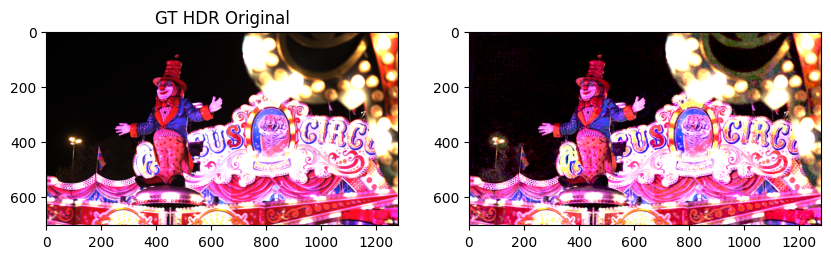

In [ ]:
import os
import cv2
def create_test_hdr_frame(height: int, width: int) -> np.ndarray:
    """
    Create a simple synthetic HDR frame in linear space with values in [0.005, 1000].
    Shape: (H, W, 3), float32, RGB.
    """
    x = np.linspace(0.0, 1.0, width, dtype=np.float32)
    y = np.linspace(0.0, 1.0, height, dtype=np.float32)
    xv, yv = np.meshgrid(x, y)
    base = (xv + yv) * 0.5  # [0, 1]

    # Map base to [0.005, 1000] to match the range used in stuttgart_dataset
    lin_min, lin_max = 0.005, 1000.0
    frame = lin_min + base * (lin_max - lin_min)

    # Three identical channels
    frame = np.stack([frame, frame, frame], axis=-1).astype(np.float32)
    return frame


def save_exr(path: str, rgb: np.ndarray) -> None:
    """
    Save an RGB float32 image as EXR using OpenCV.
    Expects rgb in shape (H, W, 3), RGB order; converts to BGR for OpenCV.
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    bgr = rgb[..., ::-1].astype(np.float32)
    cv2.imwrite(path, bgr)


def save_pu_as_png(path: str, pu: np.ndarray, pu_max: float) -> None:
    """
    Scale PU21-encoded frame from [0, pu_max] to [0, 1], clip, and save as PNG.
    pu: (H, W, 3), float; path: output path for PNG.
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    pu_01 = (pu / (pu_max + 1e-12)).clip(0.0, 1.0)
    u8 = (pu_01 * 255.0).astype(np.uint8)
    bgr = u8[..., ::-1]
    cv2.imwrite(path, bgr)


HDR_PATH = "/data2/saikiran.tedla/hdrvideo/diff/evaluations/stuttgart/hdr/carousel_fireworks_02/frame_0000.exr"
OUT_DIR = "pu21_test_frames"


from diffsynth.trainers.stuttgart_dataset import (
    _pu21_encode_frame,
    pu21_decode_frame,
    PU21_IN_MAX_VALUE,
    make_exposure_brackets,
    ImageCropAndResize,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Use a real Stuttgart HDR frame, processed through the same crop+resize as the Stuttgart dataloader.
# We fix the target resolution to 1280x704 (both divisible by 16).
frame_processor = ImageCropAndResize(
    height=704,
    width=1280,
    max_pixels=1920 * 1080,
    height_division_factor=16,
    width_division_factor=16,
    crop_size_h=None,
    crop_size_w=None,
    crf_aug=None,
)


def encode_and_decode(video):
    with torch.no_grad():
        video = video * 2.0 - 1.0  # scale to [-1, 1]
        video = video.permute(0,2,1,3,4)  # (B, T, C, H, W) to (B, C, T, H, W)
        print(video.shape)
        input_latents = pipe.vae.encode(video.to(torch.bfloat16), device=pipe.device, tiled=False).to(dtype=pipe.torch_dtype, device=pipe.device)
        output_video = pipe.vae.decode(input_latents, device=pipe.device, tiled=False).to(dtype=torch.float32, device="cpu")
        output_video = (output_video + 1.0) / 2.0  # scale to [0, 1]
        output_video = torch.clamp(output_video, 0.0, 1.0) #clip output video to [0,1]
        output_video = output_video.permute(0,2,1,3,4)  # (B, C, T, H, W) to (B, T, C, H, W)
    return output_video

data = make_exposure_brackets([HDR_PATH], frame_processor=frame_processor, crf_aug=None)
# Single-frame case: take the first frame (cropped + scaled to max 1000 in linear domain)
linear = data["hdr_frames_linear"][0]  # (H, W, 3), linear, max ~1000
pu = linear #data["hdr_frames"][0]            # (H, W, 3), PU21-encoded

# Also load and keep the original GT HDR frame (no crop/resize/scale) for reference
gt_hdr_orig = cv2.imread(HDR_PATH, cv2.IMREAD_ANYDEPTH | cv2.IMREAD_COLOR)[:, :, ::-1]
pu_frame = _pu21_encode_frame(linear)
gt_hdr_orig = np.clip(gt_hdr_orig, 0.0, 100)
gt_hdr_orig = torch.from_numpy(gt_hdr_orig).float().permute(2,0,1).unsqueeze(0).unsqueeze(0)

gt_hdr_orig_encode_decode = encode_and_decode(gt_hdr_orig/torch.max(gt_hdr_orig)) * torch.max(gt_hdr_orig)
pu_encode_decode = encode_and_decode(pu_frame/PU21_IN_MAX_VALUE) * PU21_IN_MAX_VALUE
#do imshow of gt_hdr_orig, gt_hdr_orig_encode_decode
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
print(gt_hdr_orig.shape)
plt.imshow(np.clip(gt_hdr_orig[0,0].cpu().numpy().transpose(1, 2, 0)*100/torch.max(gt_hdr_orig[0,:,0]),0,1))
plt.title("GT HDR Original")
plt.subplot(1, 2, 2)
plt.imshow(gt_hdr_orig_encode_decode[0,0].cpu().numpy().transpose(1, 2, 0)*100/torch.max(gt_hdr_orig_encode_decode[0,0]))

In [ ]:


# 6) Save frames to disk as EXR
save_exr(os.path.join(OUT_DIR, "frame_linear_input.exr"), linear)
save_exr(os.path.join(OUT_DIR, "frame_linear_decoded_direct.exr"), decoded_direct)
save_exr(os.path.join(OUT_DIR, "frame_linear_decoded_vae.exr"), decoded_vae)

# Also save GT and PU21-space frames for inspection
save_exr(os.path.join(OUT_DIR, "frame_gt_original.exr"), gt_hdr_orig)
save_exr(os.path.join(  OUT_DIR, "frame_pu_input.exr"), pu)
save_exr(os.path.join(OUT_DIR, "frame_pu_after_vae.exr"), recon_pu_frame)

# PU21 input scaled to [0,1] and saved as PNG for viewing
save_pu_as_png(os.path.join(OUT_DIR, "frame_pu_input.png"), pu, PU21_IN_MAX_VALUE)

# 7) Print basic stats for quick sanity check
mse_direct = float(np.mean((linear - decoded_direct) ** 2))
mse_vae = float(np.mean((linear - decoded_vae) ** 2))
print(f"Saved test frames to: {OUT_DIR}")
print(f"Device: {device}")
print(f"linear min/max:           {linear.min():.6f} / {linear.max():.6f}")
print(f"decoded_direct min/max:   {decoded_direct.min():.6f} / {decoded_direct.max():.6f}")
print(f"decoded_vae min/max:      {decoded_vae.min():.6f} / {decoded_vae.max():.6f}")
print(f"PU21 input min/max:       {pu.min():.6f} / {pu.max():.6f}")
print(f"PU21 after VAE min/max:   {recon_pu_frame.min():.6f} / {recon_pu_frame.max():.6f}")
print(f"MSE(linear, decoded_direct): {mse_direct:.6e}")
print(f"MSE(linear, decoded_vae):    {mse_vae:.6e}")

